Columns: Index(['hour', 'pm25', 'temperature', 'humidity', 'site', 'count', 'meanSpeed',
       'meanDuration', 'meanTPI', 'minTPI', 'minTPIId', 'maxTPI', 'maxTPIId'],
      dtype='object')
Enhanced Model Performance:
RMSE: 39.04
R² Score: 0.20


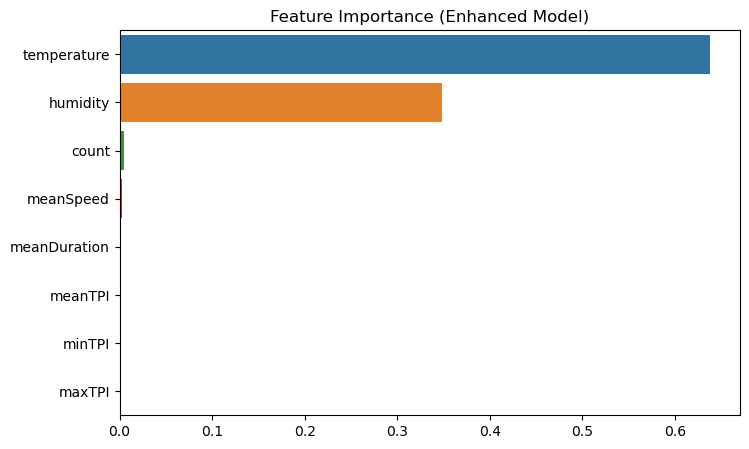

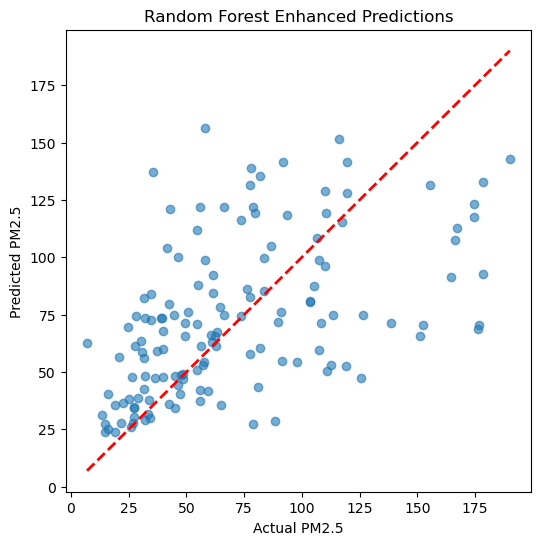

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load merged dataset
data = pd.read_json(r"E:\RSXS\Study\project\ParticulateMatterApp\data\ML\merged_record.json")

print("Columns:", data.columns)

# 2. Define features and target
X = data[[
    "temperature",
    "humidity",
    "count",
    "meanSpeed",
    "meanDuration",
    "meanTPI",
    "minTPI",
    "maxTPI"
]]
y = data["pm25"]

# 3. Drop rows missing target only
data = data.dropna(subset=["pm25"])
X = X.loc[data.index]
y = y.loc[data.index]

# 4. Impute missing values in features
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

# 6. Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# 7. Predictions
y_pred = rf_model.predict(X_test)

# 8. Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Enhanced Model Performance:")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# 9. Feature importance
importances = rf_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance (Enhanced Model)")
plt.show()

# 10. Scatter plot of predictions vs actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Random Forest Enhanced Predictions")
plt.show()